<a href="https://colab.research.google.com/github/PriyanshuChaudhary00/Ai/blob/main/Planar_Data_Classification_with_One_Hidden_Layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [107]:
import numpy as np
from sklearn.datasets import make_moons
m = 500
X, y = make_moons(
    n_samples=m,
    noise=0.2,
    random_state=42
)

In [108]:
# print(y[0])

1


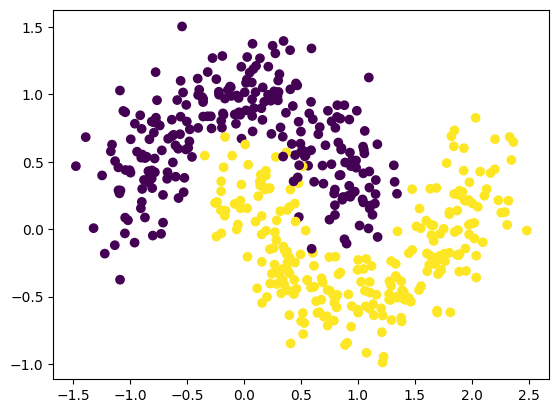

In [109]:
# import matplotlib.pyplot as plt

# plt.scatter(X[:,0], X[:,1], c=y)
# plt.show()

In [110]:
def init_parameter(n_x , n_h , n_y):
  w1 = np.random.randn(n_h , n_x)*0.01
  b1 = np.zeros((n_h , 1))
  w2 = np.random.randn(n_y , n_h)*0.01
  b2 = np.zeros((n_y , 1))

  return w1 , b1 , w2 , b2

In [111]:
w1 , b1 , w2 , b2 = init_parameter(2,4,1)
print(w1)
print(b1)
print(w2)
print(b2)

[[ 0.00232992 -0.00435584]
 [-0.01113893 -0.02219422]
 [ 0.00577896 -0.00989125]
 [ 0.00749324 -0.01222378]]
[[0.]
 [0.]
 [0.]
 [0.]]
[[-0.00198184 -0.00294762  0.00931675 -0.00358819]]
[[0.]]


In [112]:
def output(X , w1 , w2 , b1 , b2):
  z1 = w1 @ X.T + b1
  A1 = np.tanh(z1)
  z2 = w2 @ A1 + b2
  A2 = 1 / (1 + np.exp(-z2))
  return A1, A2

In [113]:
def loss( y , A2):
  temp2 = 0
  for i in range(500):
    temp = y[i] * np.log(A2[0, i]) + (1 - y[i])* np.log(1 - A2[0, i])
    temp2 += temp
  return -temp2/500

In [114]:
loss(y , A2)

np.float64(0.2880267846479224)

In [115]:
A1, A2 = output(X,w1,w2,b1,b2)

In [116]:
def backward(A1 , A2 , y , X):
  dZ_2 = A2 - y

  dW_2 = (1/m)* (dZ_2 @ A2.T)

  dB_2 = (1/m)* (np.sum(dZ_2, axis=1, keepdims=True))

  dZ_1 = w2.T @ dZ_2 * (1 - np.power(A1, 2))

  dW_1 = (1/m)* dZ_1@X

  dB_1 = (1/m)*np.sum(dZ_1, axis=1, keepdims=True)
  return dW_1 , dB_1 , dW_2 , dB_2

In [117]:
def gradient_descent(y , lr , w1 , w2 , b1 , b2 , dW_1 , dW_2 , dB_1 , dB_2):
  w1 = w1 - lr * dW_1
  b1 = b1 - lr * dB_1
  w2 = w2 - lr * dW_2
  b2 = b2 - lr * dB_2
  return w1 , b1 , w2 , b2


In [119]:
for i in range(10000):

    A1 , A2 = output(X , w1 , w2 , b1 , b2)
    cost = loss(y , A2)
    dW_1 , dB_1 , dW_2 , dB_2 = backward(A1 , A2 , y , X)
    w1 , b1 , w2 , b2 = gradient_descent(y , 0.01 , w1 , w2 , b1 , b2 , dW_1 , dW_2 , dB_1 , dB_2)

    if i % 1000 == 0:
        print(cost)


0.6800047328576427
0.6477989795115738
0.5185634835058576
0.3706720060212531
0.3170504085653414
0.2980756964237154
0.29219256672184624
0.29041804851311337
0.2897946155523472
0.2895289858951465
